# **WEEK 6 FRIDAY**

# Data Visualization: `matplotlib`

In this lecture, we'll introduce the matplotlib package for data visualization. `matplotlib` is second core library for computational and data science in Python. It works very well with numpy.

In this course, we'll only make use of tools in the matplotlib.pyplot module.

The official website is https://matplotlib.org

https://jakevdp.github.io/PythonDataScienceHandbook/index.html#4.-Visualization-with-Matplotlib

The standard way to import these tools is:

In [1]:
from matplotlib import pyplot as plt
import numpy as np

## Plotting with `matplotlib`

We've seen a few examples of using `matplotlib` functions before, e.g. when visualizing random walks. In these cases, we called `plt.plot()` and it "just worked." In order to obtain finer-grained control over our visualizations, we are going to start with the "object-oriented interface" to `matplotlib`. Here are the main ingredients: 

1. A *figure* is the overall space in which visualizations may be created. 
2. An *axis* is a single visualization (i.e. "a plot"). Figures can contain one or more axes. 

<figure class="image" style="width:80%">
  <img src="https://2.bp.blogspot.com/-F__I5bCe3uI/XRS1Y3gdP9I/AAAAAAAAHxk/plElt8VRYRMp42BuHTe9wkD29hZaPvo-ACLcBGAs/s1600/figure_axes.PNG" alt="Four blank axes (plots) with gridlines, arranged in a 2x2 grid. The four axes form a single figure">
  <figcaption><i>Image from the <a href = "https://www.listendata.com/2019/06/matplotlib-tutorial-learn-plot-python.html"> ListenData</a> matplotlib tutorial.  </i></figcaption>
</figure>

The basic workflow for `matplotlib` figures is:

1. Create a figure. 
2. Add one or more axes. 
3. Add data markers (i.e. "the plot") to the axes. 
4. Add annotation (axis labels, titles, ticks, legends)
5. Save the figure. 

Let's work through these stages. 

### 1. Create a Figure and 2. Add Axes

Unless you need something very customized, it's easiest to do these two steps simultaneously, using `plt.subplots()`: 

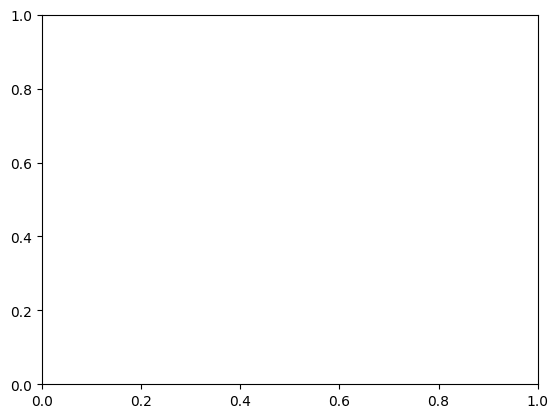

In [3]:
# create a single figure with a single axis (1 row x 1 column)
fig, ax = plt.subplots(1,1)

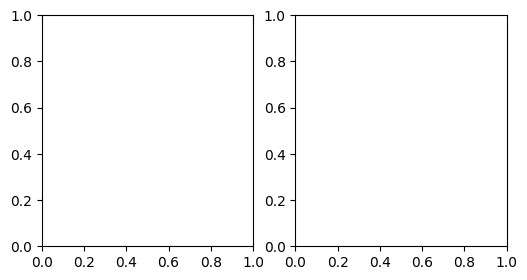

In [8]:
# two plots side by side, using figsize to stretch 
# them out to a better aspect ratio
fig, ax = plt.subplots(1,2,figsize=(6,3))

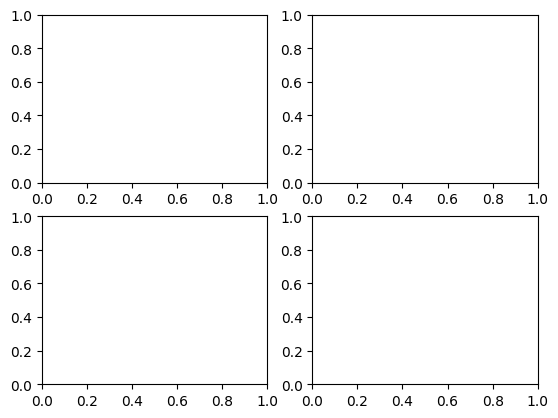

In [9]:
# 2x2 grid
fig, ax = plt.subplots(2,2)

Let's take a moment to notice what kind of object `ax` is: 

In [10]:
print(type(fig))
print(type(ax))

<class 'matplotlib.figure.Figure'>
<class 'numpy.ndarray'>


It's a `numpy` array! It's shape is: 

In [11]:
ax.shape

(2, 2)

This means, for example, that if we want the axis in the first row and second column, we can access it like this: 

In [12]:
print(ax[0,1], type(ax[0,1]))           # can do ax[0,1]

Axes(0.547727,0.53;0.352273x0.35) <class 'matplotlib.axes._axes.Axes'>


### Add Data Markers

To add data markings, we need: 

1. Data.
2. A choice of how to visualize that data. 
3. An axis on which to put the data. 

(2,)

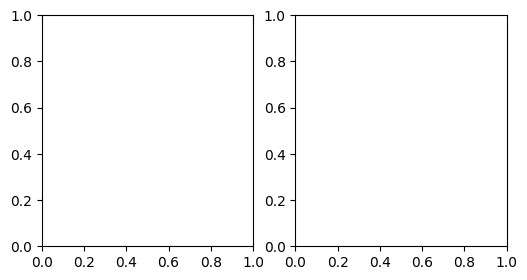

In [15]:
fig, ax = plt.subplots(1,2, figsize=(6,3))
ax.shape

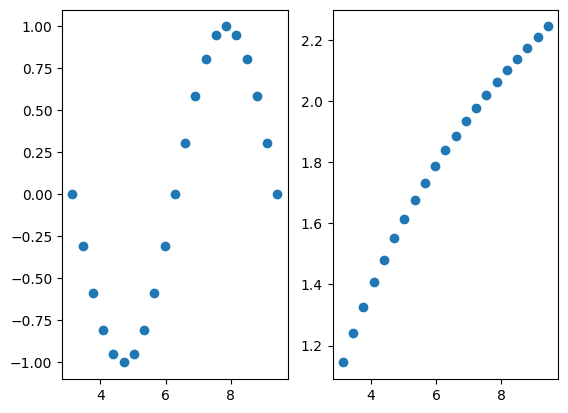

In [37]:
fig, ax = plt.subplots(1,2)
x = np.linspace(np.pi, 3*np.pi, 21)
y = np.sin(x)
z = np.log(x)

ax[0].scatter(x,y, label='hi')
ax[1].scatter(x,z, label = 'hello')

In [20]:
# something to plot
x = np.linspace(np.pi, 3 * np.pi, 21)
y = np.sin(x)
z = np.log(x)

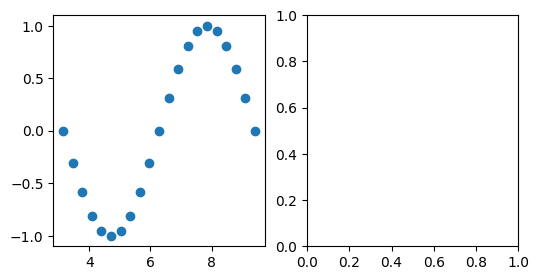

In [21]:
ax[0].scatter(x,y)
fig

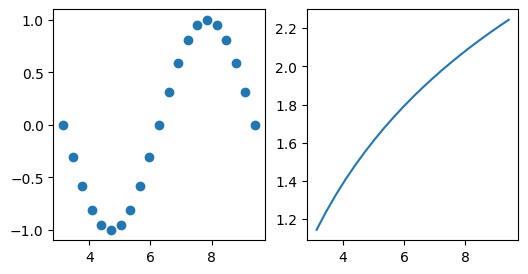

In [22]:
ax[1].plot(x,z,label='bestLogarithmic')
fig

You can add as many layers as you want: 

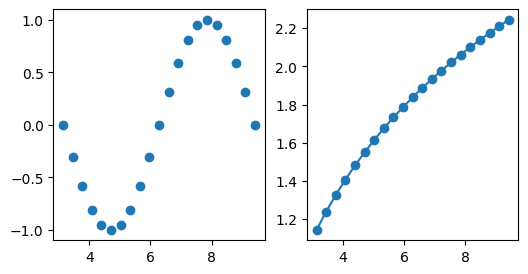

In [23]:
ax[1].scatter(x,z)
fig

### Annotations

Don't forget to label your axes!! We can also add axis titles and an overall figure title. 

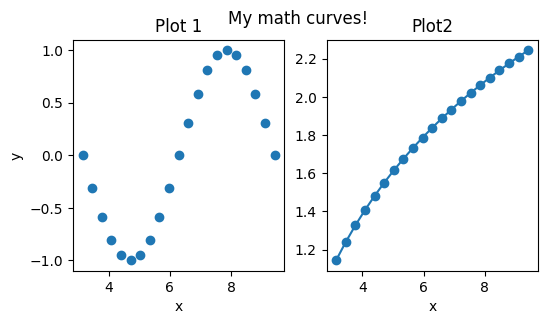

In [25]:
ax[0].set(xlabel='x', ylabel='y', title='Plot 1')
ax[1].set(xlabel='x', title='Plot2')
fig.suptitle('My math curves!')
fig

When layering similar kinds of data markings, `matplotlib` will usually change the color each time. If you `label` your markings, then you'll be able to tell them apart with a `legend()`.  

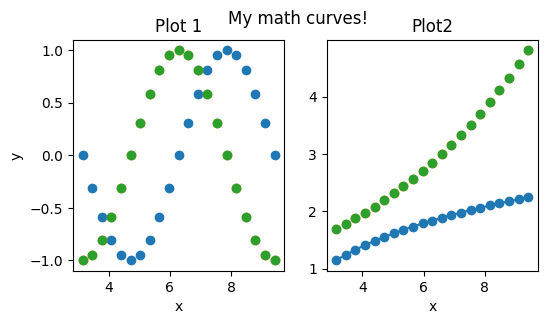

In [28]:
ax[0].scatter(x,np.cos(x))
ax[1].scatter(x,np.exp(x/6), label = 'bestExponential')
fig

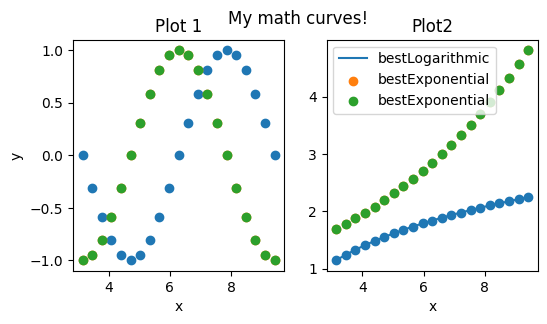

In [29]:
ax[1].legend()
fig

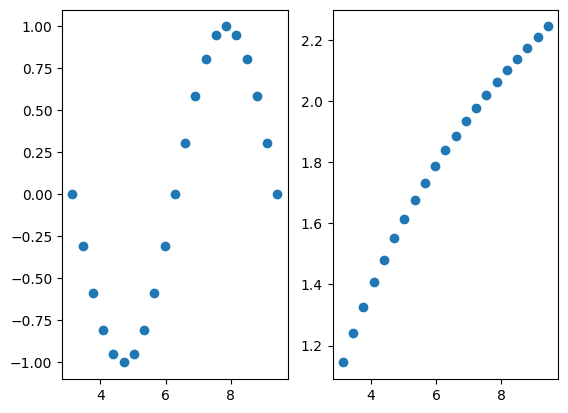

In [38]:
fig, ax = plt.subplots(1,2)
x = np.linspace(np.pi, 3* np.pi, 21)
y = np.sin(x)
z = np.log(x)
ax[0].scatter(x,y)
ax[1].scatter(x,z)

### Save the Figure

Once you're happy with how the figure looks, you can save it in one of several file formats using the `savefig()` method. PNG is usually a good choice. 

In [30]:
fig.savefig('my_math_curves.jpg')

We now have the basic components in place to create figures with multiple axes, populate them with data markings, annotate them, and save the results. Next, we'll look at plotting 2d data, including mathematical functions and images. 

## 2D Plotting

Often we want to visualize data with two independent variables. In this case, your "go-to" function should usually be `plt.imshow()`. Let's see how it works. 

### Example 1
Here's how we'll plot the function 

$$z = \sin(x) + \cos(y)$$

In [39]:
# horizontal and vertical axes
x = np.linspace(0,2*np.pi, 101)
y = np.linspace(0,2*np.pi,101)

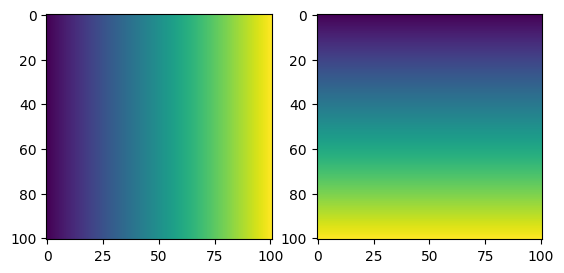

In [40]:
# meshgrid turns each into a 2d array
X,Y = np.meshgrid(x,y)
fig, ax = plt.subplots(1,2)
ax[0].imshow(X)
ax[1].imshow(Y)

(101, 101)


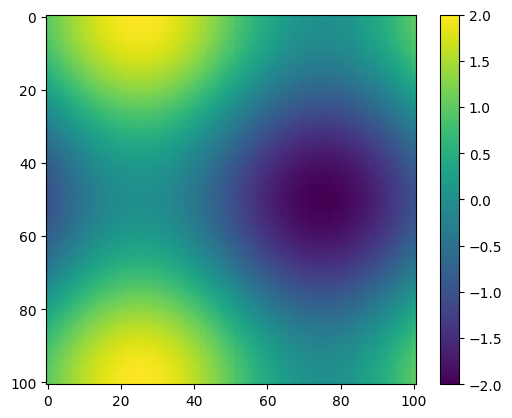

In [41]:
# compute the function values
Z = np.sin(X) + np.cos(Y)
print(Z.shape)
# add a colorbar to help interpret the scales. 
fig, ax = plt.subplots(1,1)
im=ax.imshow(Z)


# add color bar!
plt.colorbar(im)

### Plotting Images

The `ax.imshow()` method is actually strikingly versatile, and can plot RGB color data when used with `numpy` arrays of the correct data type. This allows us to use `imshow()` to inspect images, for example, those that we read in from files. 

In [38]:
import matplotlib.image as mpimg

img = mpimg.imread('semicolons.jpg')

# This is a 735x500 image. Each pixel has an RGB value, represented as 3 numbers
print(img.shape)

(500, 735, 3)


Text(0.5, 0.98, 'C++ Programmers be like:')

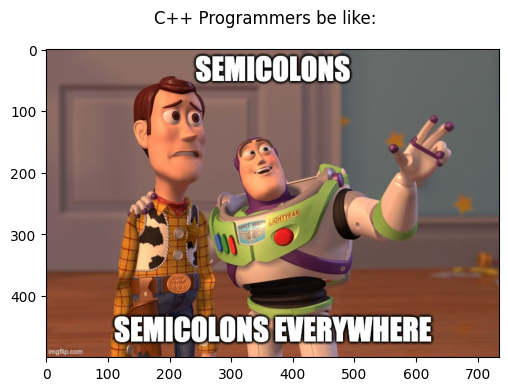

In [40]:
fig, ax = plt.subplots(1,figsize=(6,4))
ax.imshow(img)
fig.suptitle('C++ Programmers be like:')

## Statistical Graphics: Histograms and Box Plots

Quite often, it's most insightful to visualize not "raw" data points, but rather some distributional information about the points. Histograms and box plots are three of the most common statistical graphics for visualizing distributional properties of data. 

## 1d Histograms

In [42]:
# 1000 random normal variables
x = np.random.rand(1000)
print(type(x),x.shape)

<class 'numpy.ndarray'> (1000,)


(array([50., 48., 50., 51., 52., 54., 45., 48., 49., 53.]),
 array([6.80192240e-04, 9.98760967e-02, 1.99072001e-01, 2.98267906e-01,
        3.97463810e-01, 4.96659714e-01, 5.95855619e-01, 6.95051523e-01,
        7.94247428e-01, 8.93443332e-01, 9.92639237e-01]),
 <BarContainer object of 10 artists>)

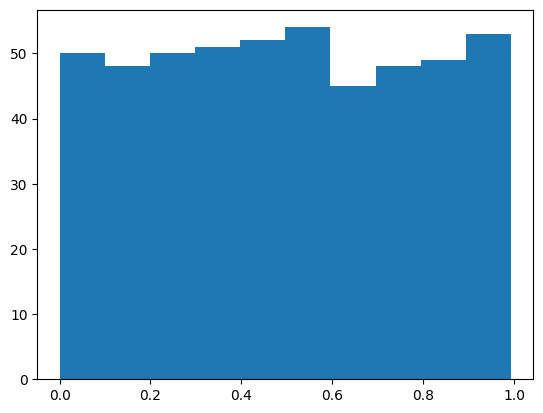

In [44]:
x = np.random.rand(500)
fig, ax = plt.subplots(1)
ax.hist(x)

(array([ 86., 101., 101.,  88., 105., 108., 105., 105., 101., 100.]),
 array([3.32885857e-04, 1.00285411e-01, 2.00237937e-01, 3.00190463e-01,
        4.00142988e-01, 5.00095514e-01, 6.00048040e-01, 7.00000565e-01,
        7.99953091e-01, 8.99905616e-01, 9.99858142e-01]),
 <BarContainer object of 10 artists>)

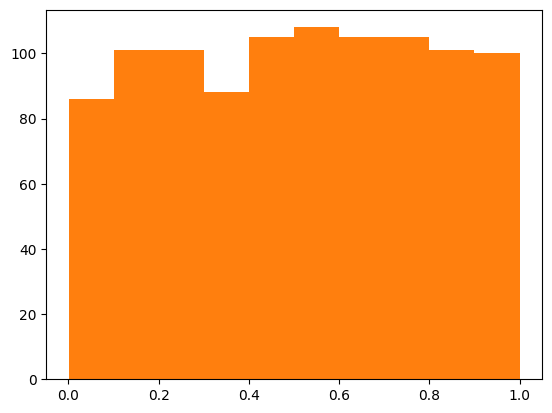

In [43]:
# automatically chooses a binwidth, usually pretty smart
fig, ax = plt.subplots(1)
h = ax.hist(x)

ax.hist(x)

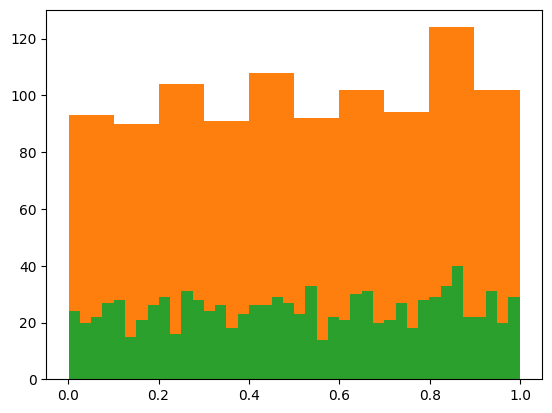

In [44]:
# same data, in finer bins
ax.hist(x,bins=40)
fig

When comparing distributions of several data sets, it's often useful to use *transparency* via the keyword `alpha`. `alpha = 1` generates fully opaque data markings, while `alpha = 0` is fully transparent (and therefore invisible). 

In [45]:
x1 = np.random.normal(0,0.8,1000)
x2 = np.random.normal(-2,1,1000)
x3 = np.random.normal(1,2,1000)

(array([  2.,   9.,  32., 108., 176., 264., 207., 146.,  40.,  16.]),
 array([-6.16565952, -4.8862546 , -3.60684968, -2.32744476, -1.04803984,
         0.23136509,  1.51077001,  2.79017493,  4.06957985,  5.34898477,
         6.6283897 ]),
 <BarContainer object of 10 artists>)

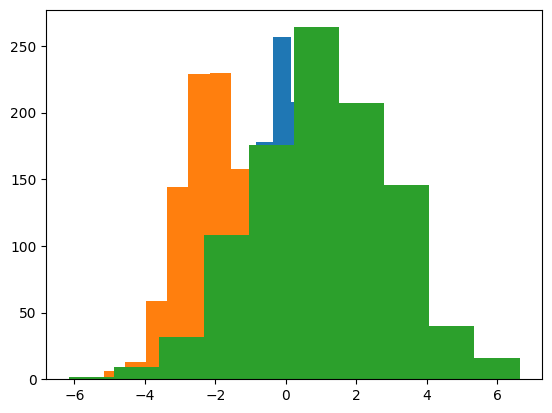

In [46]:
fig,ax = plt.subplots(1)
ax.hist(x1)
ax.hist(x2)
ax.hist(x3)

(array([ 1.,  0.,  0.,  1.,  2.,  0.,  4.,  3.,  7.,  2.,  9., 14., 24.,
        19., 31., 34., 41., 50., 37., 48., 57., 65., 60., 82., 52., 54.,
        53., 48., 43., 35., 40., 28., 11., 11.,  8., 10., 12.,  1.,  1.,
         2.]),
 array([-6.16565952, -5.84580829, -5.52595706, -5.20610583, -4.8862546 ,
        -4.56640337, -4.24655214, -3.92670091, -3.60684968, -3.28699845,
        -2.96714722, -2.64729599, -2.32744476, -2.00759353, -1.6877423 ,
        -1.36789107, -1.04803984, -0.7281886 , -0.40833737, -0.08848614,
         0.23136509,  0.55121632,  0.87106755,  1.19091878,  1.51077001,
         1.83062124,  2.15047247,  2.4703237 ,  2.79017493,  3.11002616,
         3.42987739,  3.74972862,  4.06957985,  4.38943108,  4.70928231,
         5.02913354,  5.34898477,  5.668836  ,  5.98868724,  6.30853847,
         6.6283897 ]),
 <BarContainer object of 40 artists>)

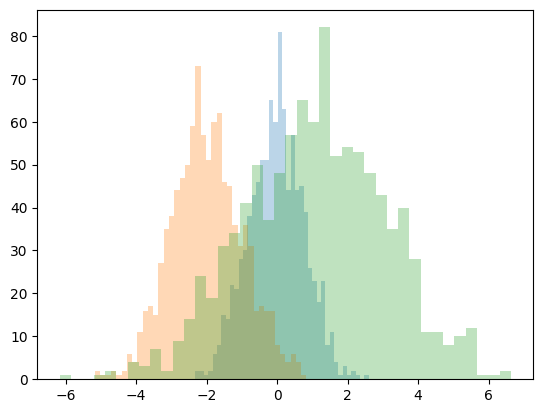

In [47]:
fig, ax = plt.subplots()
ax.hist(x1, bins =40, alpha= 0.3)
ax.hist(x2, bins =40, alpha= 0.3)
ax.hist(x3, bins =40, alpha= 0.3)

Box plot

{'whiskers': [<matplotlib.lines.Line2D at 0x10fac8830>,
 'caps': [<matplotlib.lines.Line2D at 0x10fac8ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x10fac86e0>,
 'medians': [<matplotlib.lines.Line2D at 0x10fac8d70>,
 'fliers': [<matplotlib.lines.Line2D at 0x10fac8ec0>,
 'means': []}

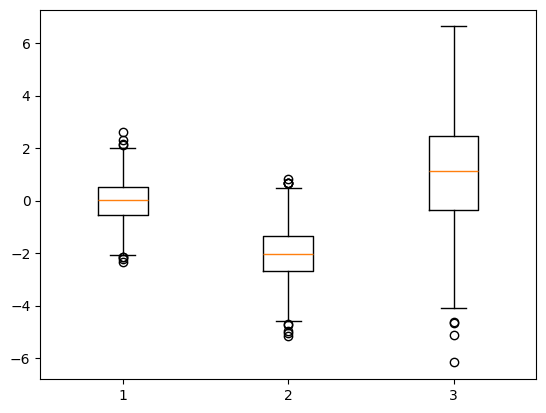

In [49]:
fig, ax = plt.subplots(1)
ax.boxplot([x1,x2,x3])

#box = ax.boxplot([x1,x2,x3])

### 2d Histograms

Histograms are also an excellent way to visualize relationships between variables. 

In [50]:
import numpy as np
from matplotlib import pyplot as plt

mean = [0,0]
cov = [[1,1],[1,2]]
x,y = np.random.multivariate_normal(mean, cov, 10000).T
x.shape, y.shape

((10000,), (10000,))

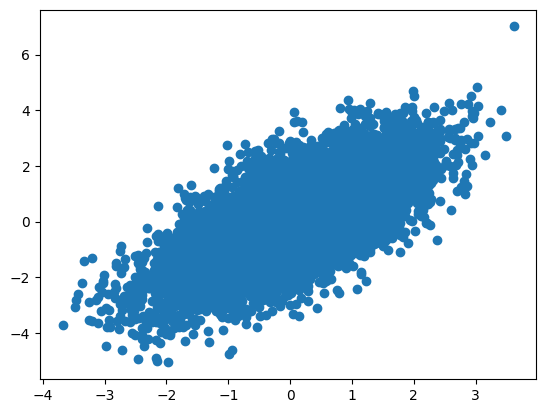

In [51]:
plt.scatter(x,y)

<class 'tuple'>


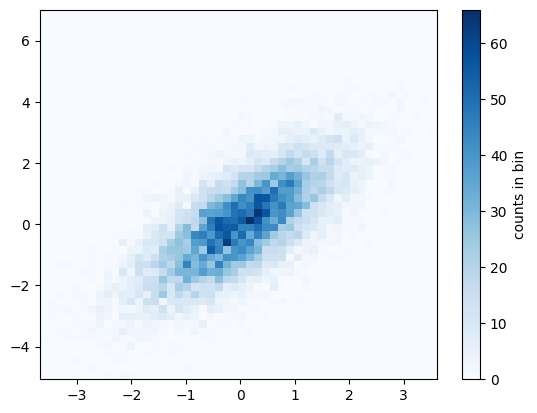

In [52]:
# h[3]: annoying syntax thing to memorize or look up
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist2d.html
fig, ax = plt.subplots(1)
h = ax.hist2d(x,y,bins=50,cmap='Blues')
print(type(h))
plt.colorbar(h[3], label = 'counts in bin')

While there's often no problem with square grids, hexagonal grids often look a bit nicer. Note that the relevant keyword for hexagonal grids is `gridsize` rather than `bins`. 

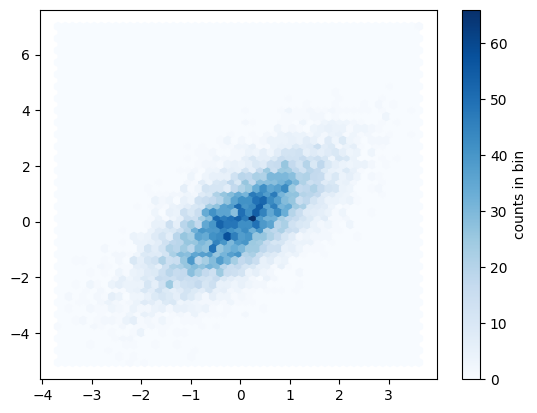

In [53]:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hexbin.html
fig,ax = plt.subplots(1)
h = ax.hexbin(x,y,gridsize = 50, cmap='Blues')
plt.colorbar(h, label = 'counts in bin')